In [1]:
import os

# Target physical GPU 3 according to nvidia-smi indexing
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"

import yaml
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch.nn.functional as F
from configargparse import Namespace

# Load YAML configuration file
config_path = "configs/test/qualitative_biosr.yaml"

with open(config_path, "r") as f:
    config_dict = yaml.safe_load(f)

args = Namespace(**config_dict)
print(f"Loaded configuration from '{config_path}'.")
print(f"Targeting physical GPU 3 via CUDA_VISIBLE_DEVICES={os.environ['CUDA_VISIBLE_DEVICES']}")

Loaded configuration from 'configs/test/qualitative_biosr.yaml'.
Targeting physical GPU 3 via CUDA_VISIBLE_DEVICES=3


In [2]:
def to_numpy_image(tensor: torch.Tensor) -> np.ndarray:
    """Converts a PyTorch single-channel image tensor [C, H, W] or [H, W] to a 2D NumPy array."""
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.detach().cpu().squeeze()
    img = tensor.numpy() if isinstance(tensor, torch.Tensor) else tensor
    return np.clip(img, 0, 1)

def plot_sr_paper_figure(
    target_img: torch.Tensor,
    wf_img: torch.Tensor,
    predictions: dict[str, torch.Tensor],
    roi_box: tuple[int, int, int, int] = None,
    figure_title: str = "SIM Super-Resolution Comparison"
):
    """
    Plots a publication-style Super-Resolution figure:
    - Left: Full Field of View (Ground Truth) with ROI bounding box.
    - Middle: Blank visual separation space.
    - Right: Row of zoomed-in patches (Widefield, Methods, GT).
    """
    gt_np = to_numpy_image(target_img)
    wf_np = to_numpy_image(wf_img)
    
    # Order: Widefield -> Model Predictions -> Ground Truth
    methods = {"Widefield": wf_np}
    for name, pred in predictions.items():
        methods[name] = to_numpy_image(pred)
    methods["Ground Truth"] = gt_np

    num_methods = len(methods)
    h_img, w_img = gt_np.shape

    # Default ROI patch if none specified
    if roi_box is None:
        patch_size = min(h_img, w_img) // 4
        y_top = (h_img - patch_size) // 2
        x_left = (w_img - patch_size) // 2
        roi_box = (y_top, x_left, patch_size, patch_size)

    y, x, h, w = roi_box

    # Layout: [Full FOV] (width ~ 3.2) | [Spacer] (width 0.25) | [Patch 1] [Patch 2] ... (width 1.0 each)
    width_ratios = [3.2, 0.25] + [1.0] * num_methods
    total_cols = len(width_ratios)

    fig = plt.figure(figsize=(3.5 + 2.2 * num_methods, 4.2), dpi=150)
    gs = fig.add_gridspec(1, total_cols, width_ratios=width_ratios, wspace=0.06)

    # 1. Full FOV Ground Truth (Left side)
    ax_main = fig.add_subplot(gs[0, 0])
    ax_main.imshow(gt_np, cmap="magma")
    roi_rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="cyan", facecolor="none")
    ax_main.add_patch(roi_rect)
    ax_main.set_title("Full FOV (GT)", fontsize=11, fontweight="bold", pad=8)
    ax_main.axis("off")

    # Column index 1 is intentionally skipped to create the visual gap

    # 2. Comparison Patches (Right side)
    for idx, (method_name, img_data) in enumerate(methods.items()):
        ax_patch = fig.add_subplot(gs[0, 2 + idx])
        patch = img_data[y : y + h, x : x + w]
        ax_patch.imshow(patch, cmap="magma")
        ax_patch.set_title(method_name, fontsize=10, fontweight="bold", pad=8)
        ax_patch.axis("off")

    fig.suptitle(figure_title, fontsize=13, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.show()

In [3]:
import torch
from src.simulation.sim_pipeline import SimulatorPipeline
from src.train.datasets import get_data

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

# 1. Initialize Microscope Simulator
simulator = SimulatorPipeline.from_file(
    args.microscope_config, args.noise_config
).to(device=device)

# 2. Load Test Dataset
_, _, test_loader = get_data(
    args.dataset,
    args.test_size,
    args.first_crop,
    args.split,
    args.batch_size,
    args.num_workers,
)

# Store model specification tuples for sequential GPU loading
model_specs = list(zip(args.model_names, args.model_configs, args.checkpoints))
print(f"Dataset & Simulator initialized. {len(model_specs)} models queued for sequential GPU evaluation.")

/home/msiau/workspace/XL_SIM-HPC/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on device: cuda:0
Computing Excitation 1.6 %
Computing Excitation 10.9 %
Computing Excitation 20.3 %
Computing Excitation 29.7 %
Computing Excitation 39.1 %
Computing Excitation 48.4 %
Computing Excitation 57.8 %
Computing Excitation 67.2 %
Computing Excitation 76.6 %
Computing Excitation 85.9 %
Computing Excitation 95.3 %
Microscope ready!
Dataset & Simulator initialized. 5 models queued for sequential GPU evaluation.


--> Loading model 'GSASR' onto GPU...


/home/msiau/workspace/XL_SIM-HPC/.venv/lib/python3.13/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4215.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


    Finished 'GSASR'. Model purged from VRAM.
--> Loading model 'HAT' onto GPU...
    Finished 'HAT'. Model purged from VRAM.
--> Loading model 'Swin2SR' onto GPU...
    Finished 'Swin2SR'. Model purged from VRAM.
--> Loading model 'XLSIM' onto GPU...
    Finished 'XLSIM'. Model purged from VRAM.
--> Loading model 'RL' onto GPU...
    Finished 'RL'. Model purged from VRAM.


/home/msiau/data/tmp/agarciat/tmp/ipykernel_2683401/2298541296.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


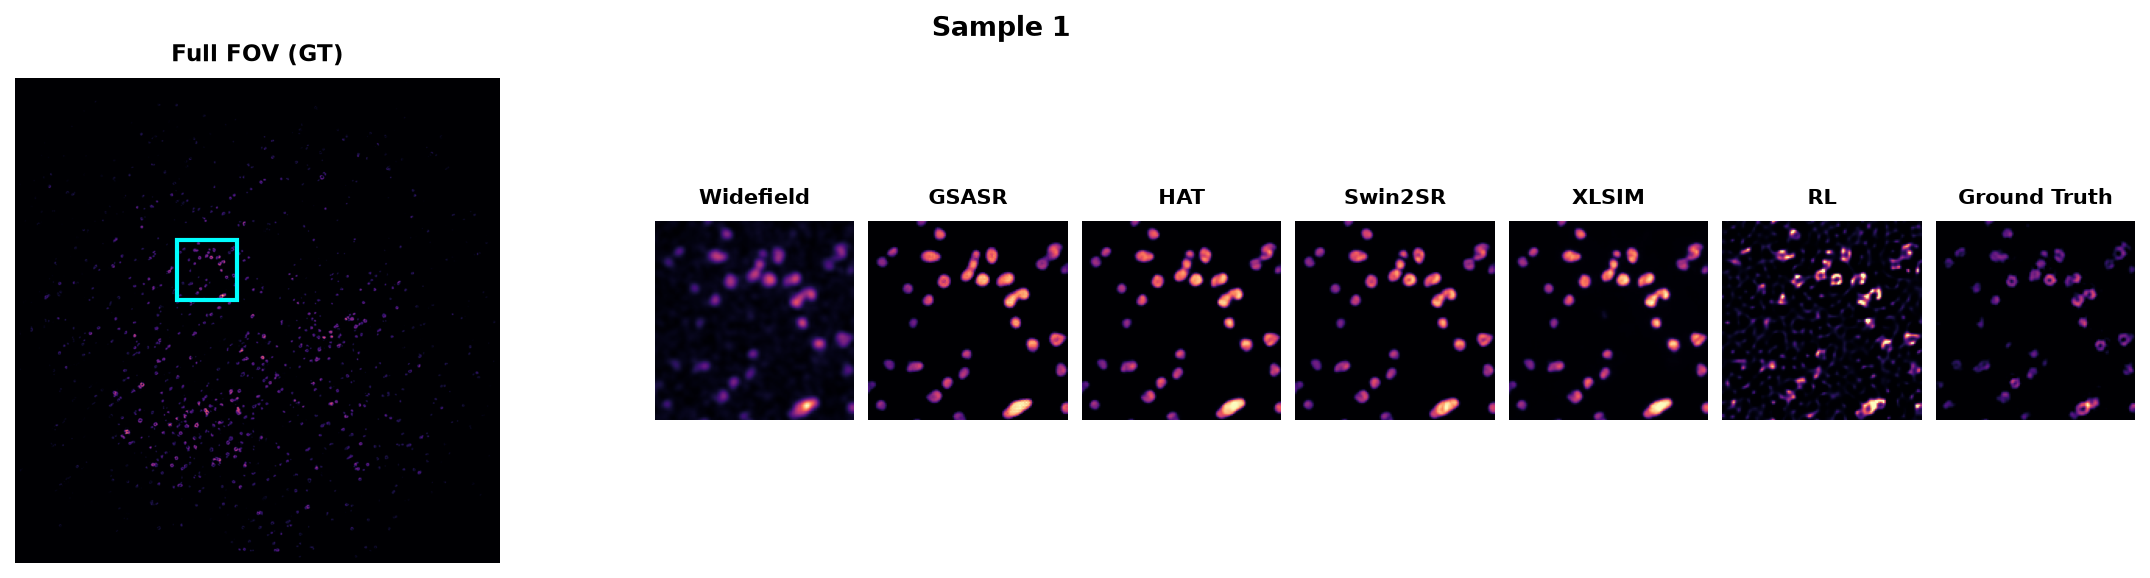

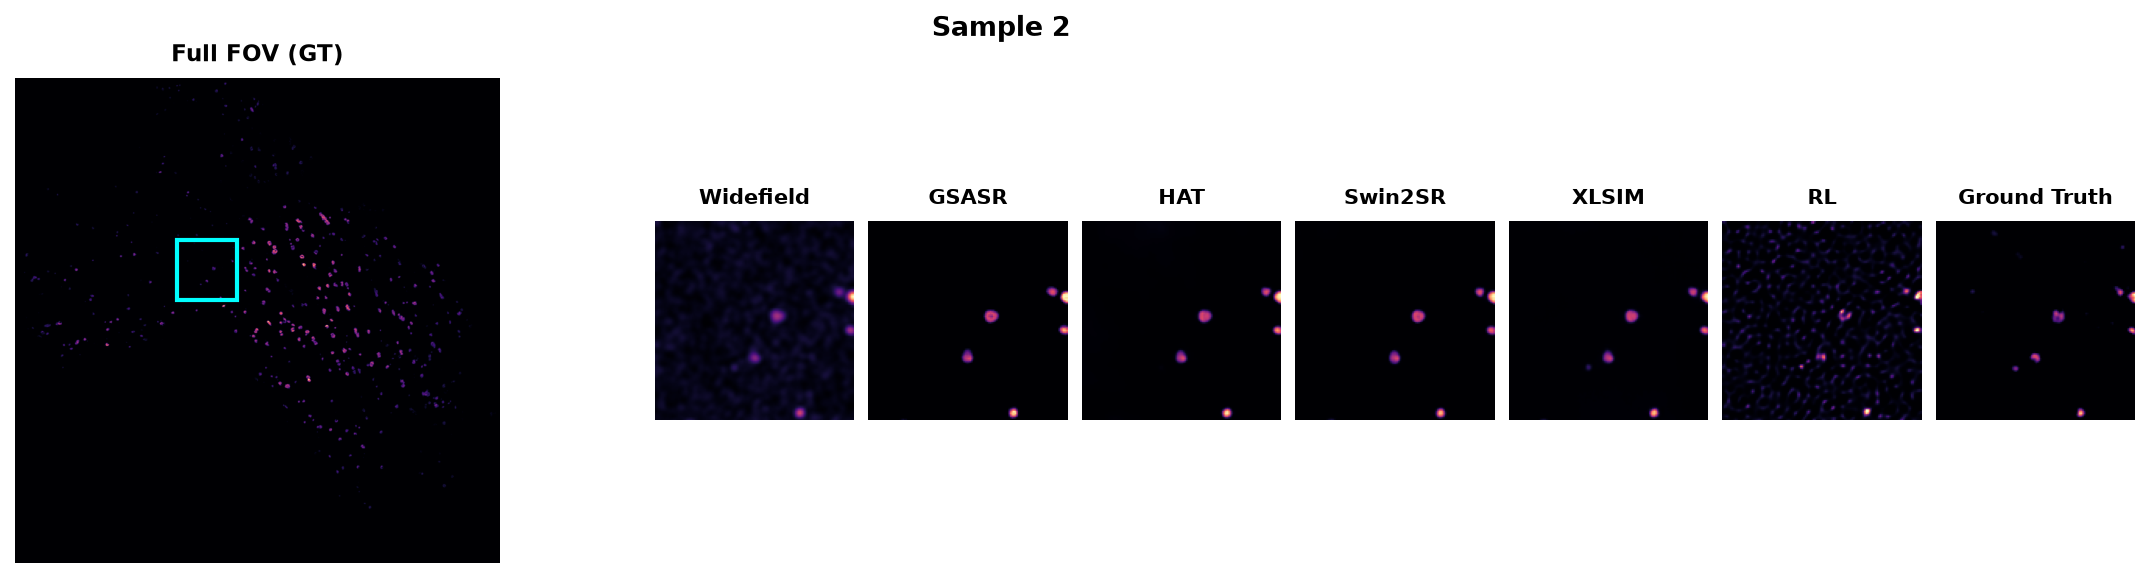

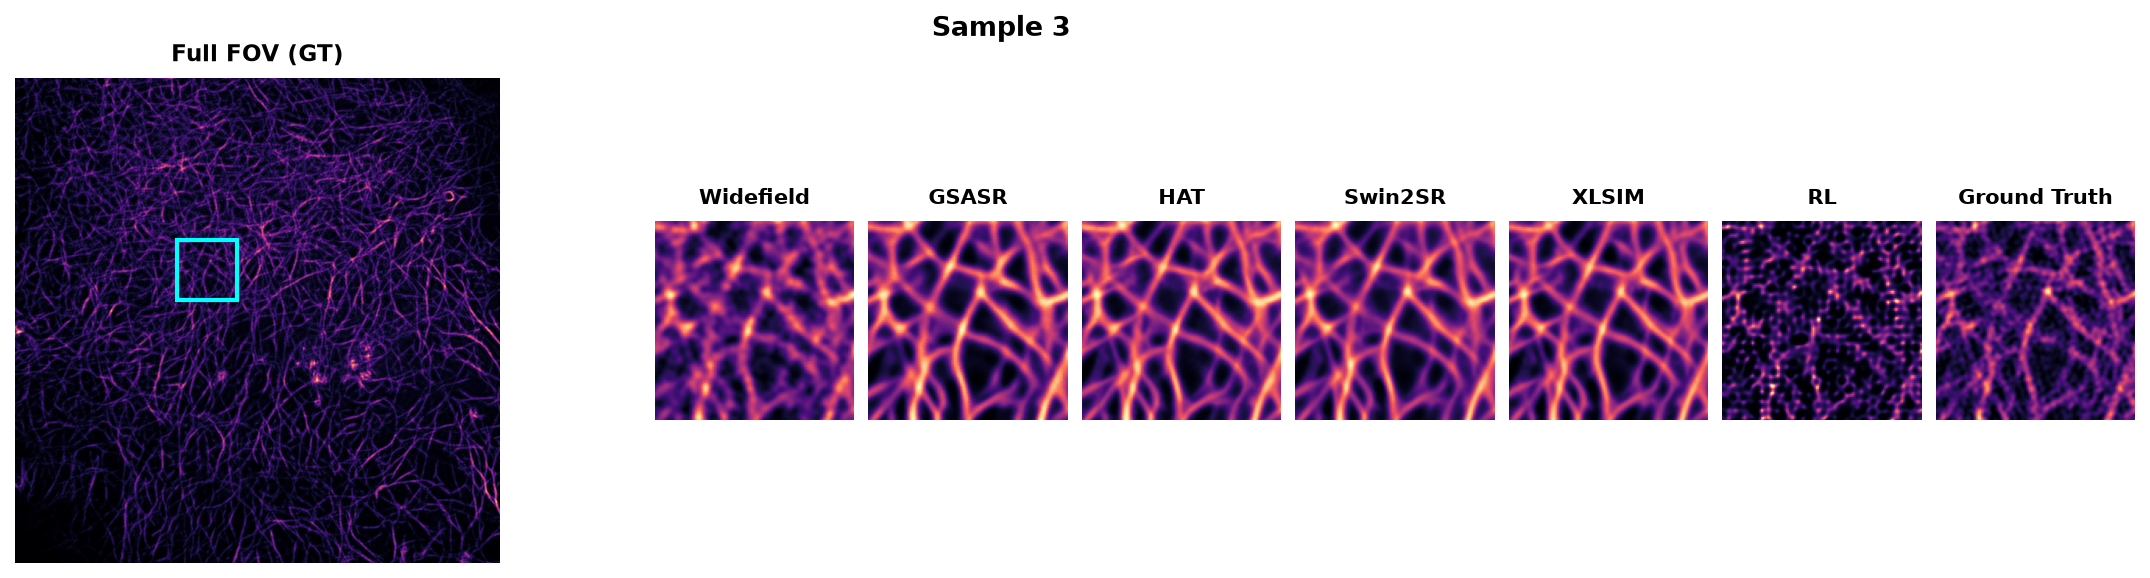

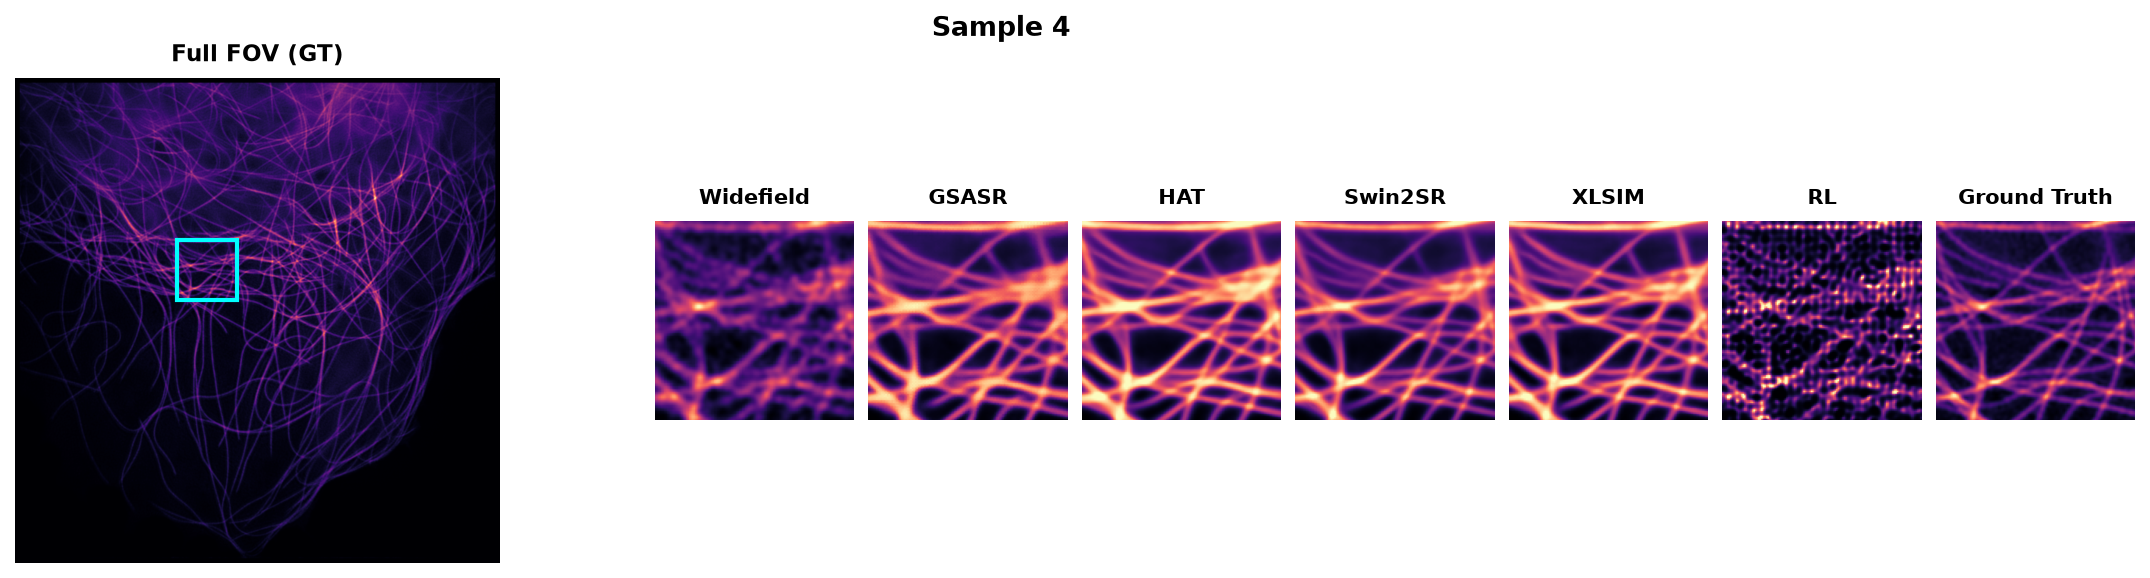

In [ ]:
import gc
import random
import torch.nn.functional as F
from src.models import get_model
from src.utils.preprocessing import crop_tensor

# 1. Select 4 random samples from the dataset
dataset_batches = list(test_loader)
random.seed(42)
selected_indices = random.sample(range(len(dataset_batches)), min(4, len(dataset_batches)))

# 2. Pre-simulate SIM microscopy inputs for all 4 selected samples
samples_data = []
with torch.inference_mode():
    for sample_idx in selected_indices:
        print(f"Idx: {sample_idx}")
        batch = dataset_batches[sample_idx]
        targets = batch["hr"].to(device=device)
        target_padding = batch["padding"]

        pixel_values, calibs = simulator(targets)
        pixel_values, targets, _ = crop_tensor(
            pixel_values,
            args.second_crop,
            pair_image=targets,
            pair_scale_factor=args.upscale,
            offset=target_padding.max(dim=0).values // (2 * args.upscale),
            mode="center",
        )
        psf = simulator.microscope.psf_em

        # Widefield estimation
        wf_raw = pixel_values.mean(dim=1, keepdim=True)
        wf_upsampled = F.interpolate(wf_raw, scale_factor=args.upscale, mode="bicubic")

        samples_data.append({
            "targets": targets,
            "pixel_values": pixel_values,
            "calibs": calibs,
            "psf": psf,
            "wf_upsampled": wf_upsampled,
            "predictions": {}
        })

# 3. Evaluate ONE model at a time on GPU and unload immediately
for name, cfg, ckpt in model_specs:
    print(f"--> Loading model '{name}' onto GPU...")
    ckpt_path = ckpt if ckpt != "" else None

    model, preprocess_fn, postprocess_fn = get_model(
        name,
        cfg,
        ckpt_path,
        args.lora,
        lora=args.lora,
        lora_r=args.lora_r,
        lora_alpha=args.lora_alpha,
        lora_dropout=args.lora_dropout,
        lora_target_modules=args.lora_target_modules,
        lora_bias=args.lora_bias,
    )
    model = model.to(device=device)

    if args.lora and callable(getattr(model, "merge_and_unload", None)):
        model = model.merge_and_unload()

    model.eval()

    # Run inference across all 4 samples for current model
    with torch.inference_mode():
        for sample in samples_data:
            preprocessed = preprocess_fn(
                pixel_values=sample["pixel_values"],
                psf=sample["psf"],
                calibs=sample["calibs"],
                upscale=args.upscale
            )

            outputs = model(**preprocessed)

            try:
                preds = postprocess_fn(outputs, target=sample["targets"])
            except TypeError:
                preds = postprocess_fn(outputs)

            # Store result directly in CPU RAM
            sample["predictions"][name] = preds[0].cpu()

    # Explicitly clear model from GPU VRAM
    del model
    del preprocess_fn
    del postprocess_fn
    gc.collect()
    torch.cuda.empty_cache()
    print(f"    Finished '{name}'. Model purged from VRAM.")

# 4. Render publication figures for each sample
for fig_num, sample in enumerate(samples_data, start=1):
    H, W = sample["targets"][0, 0].shape
    patch_sz = 128
    roi = (H // 3, W // 3, patch_sz, patch_sz)

    plot_sr_paper_figure(
        target_img=sample["targets"][0, 0].cpu(),
        wf_img=sample["wf_upsampled"][0, 0].cpu(),
        predictions=sample["predictions"],
        roi_box=roi,
        figure_title=f"Sample {fig_num}"
    )